In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
df = pd.read_csv("../content/housing.csv")

In [ ]:
df.columns


Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [ ]:
import numpy as np

target_col = 'median_house_value'
feature_df = df.drop(columns=drop_cols).select_dtypes(include=[np.number])
feature_df = feature_df.fillna(feature_df.mean())

x = feature_df.values
y = df[target_col].values.reshape(-1, 1)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

In [ ]:
x_train_b = np.c_[np.ones((x_train.shape[0],1)),x_train]
x_test_b = np.c_[np.ones((x_test.shape[0],1)),x_test]

In [ ]:
def gradient_descent(x, y, lr=0.01, n_iters=1000):
  m, n = x.shape
  theta = np.zeros((n,1))
  losses = []

  for i in range(n_iters):
    y_pred = x @ theta
    error = y_pred - y

    loss = (1/(2*m)) * np.sum(error**2)
    losses.append(loss)

    gradient = (1/m) * (x.T @ error)
    theta -= lr * gradient

    if i % 100 == 0:
      print(f"Iteration {i:4d}: Loss = {loss:.4f}")

  return theta, losses

theta, losses = gradient_descent(x_train_b, y_train, lr=0.01, n_iters=1000)

Iteration    0: Loss = 28148711615.5157
Iteration  100: Loss = 3586629584.3630
Iteration  200: Loss = 682373399.8020
Iteration  300: Loss = 217540300.1780
Iteration  400: Loss = 102516741.4493
Iteration  500: Loss = 56560140.9845
Iteration  600: Loss = 32833139.7916
Iteration  700: Loss = 19520578.8006
Iteration  800: Loss = 11865586.4822
Iteration  900: Loss = 7414938.6953


In [ ]:
y_pred = x_test_b @ theta
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nFinal weights (theta):")
print(theta.ravel())
print(f"\nTest MSE : {mse:.4f}")
print(f"Test R^2 : {r2:.4f}")


Final weights (theta):
[207185.7488845    1289.12374084  -4746.45662911   3083.30066715
   2069.4015222    4904.33513214 111492.09870941]

Test MSE : 10368055.7074
Test R^2 : 0.9992


In [ ]:
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression()
sk_model.fit(x_train, y_train)
sk_pred = sk_model.predict(x_test)
print(f"\nSklearn LinearRegression R^2 : {r2_score(y_test, sk_pred):.4f}")


Sklearn LinearRegression R^2 : 1.0000



Saved plots to gradient_descent_plots.png


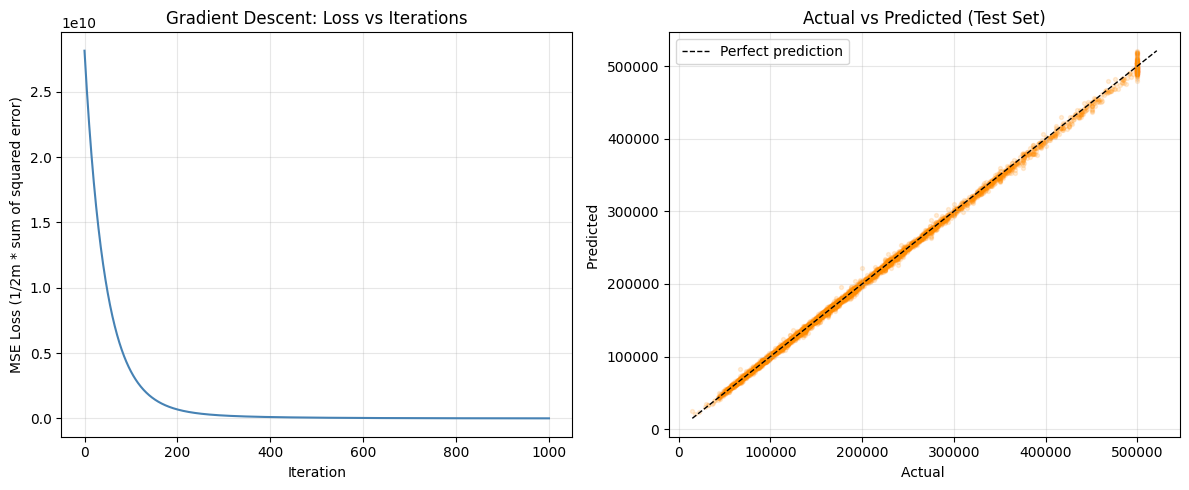

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(range(len(losses)), losses, color="steelblue")
axes[0].set_title("Gradient Descent: Loss vs Iterations")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE Loss (1/2m * sum of squared error)")
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test, y_pred, alpha=0.15, s=8, color="darkorange")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lims, lims, color="black", linestyle="--", linewidth=1, label="Perfect prediction")
axes[1].set_title("Actual vs Predicted (Test Set)")
axes[1].set_xlabel("Actual ")
axes[1].set_ylabel("Predicted ")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("gradient_descent_plots.png", dpi=150)
print("\nSaved plots to gradient_descent_plots.png")
plt.show()